In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Parámetros Iniciales del Movimiento ---
velocidad_inicial = 50.0  # m/s
angulo_grados = 45.0      # grados
gravedad = 9.81           # m/s^2

# Convertir el ángulo a radianes
angulo_radianes = np.deg2rad(angulo_grados)

# Componentes de la velocidad inicial
v0x = velocidad_inicial * np.cos(angulo_radianes)
v0y = velocidad_inicial * np.sin(angulo_radianes)

# --- Generación de Datos Sintéticos (Tiempo) ---
# Tiempo de vuelo teórico (para definir el rango de tiempo)
tiempo_vuelo = 2 * v0y / gravedad
num_puntos = 100  # Aumentamos los puntos para un mejor entrenamiento posterior

# Vector de tiempo
t = np.linspace(0, tiempo_vuelo, num_puntos)

# --- Cálculo de la Trayectoria Ideal (Sin Ruido) ---
# Posición horizontal (x) ideal: x(t) = v0x * t
x_ideal = v0x * t

# Posición vertical (y) ideal: y(t) = v0y * t - 0.5 * g * t^2
y_ideal = v0y * t - 0.5 * gravedad * t**2

# --- Adición de Ruido Gaussiano (Normal) ---
# Definir la desviación estándar (sigma) para el ruido
# Un valor más alto significa más ruido.
sigma_ruido = 5.0

# Generar ruido para la posición x e y
ruido_x = np.random.normal(0, sigma_ruido, num_puntos)
ruido_y = np.random.normal(0, sigma_ruido, num_puntos)

# Sumar el ruido a la trayectoria ideal
x_ruido = x_ideal + ruido_x
y_ruido = y_ideal + ruido_y

# --- Visualización de Resultados ---
plt.figure(figsize=(10, 6))

# Trazar la trayectoria ideal
plt.plot(x_ideal, y_ideal, label='Trayectoria Ideal (Sin Ruido)', color='blue', linestyle='--')

# Trazar los datos sintéticos con ruido (como puntos)
plt.scatter(x_ruido, y_ruido, label='Datos Sintéticos con Ruido', color='red', marker='o', s=15)

plt.title('Movimiento Parabólico con Datos Sintéticos y Ruido')
plt.xlabel('Posición Horizontal (x) [m]')
plt.ylabel('Posición Vertical (y) [m]')
plt.ylim(bottom=0) # Asegura que la gráfica empiece en y=0
plt.grid(True)
plt.legend()
plt.show()

# --- Mostrar los parámetros y un ejemplo de datos ---
print(f"\nVelocidad Inicial: {velocidad_inicial} m/s")
print(f"Ángulo de Disparo: {angulo_grados}°")
print(f"Desviación Estándar del Ruido: {sigma_ruido} m")
print(f"\nPrimeros 5 puntos de datos con ruido:")
print(f"Tiempo (s):    {t[:5]}")
print(f"Posición X (m): {x_ruido[:5]}")
print(f"Posición Y (m): {y_ruido[:5]}")

: 

Forma de los datos de entrada (Tiempo): (1000, 1)
Forma de los datos de salida (Posición X, Y): (1000, 2)

Iniciando entrenamiento...
Entrenamiento finalizado.

Error Cuadrático Medio (MSE) en Test: 0.0441
Error Absoluto Medio (MAE) en Test: 0.1437

Arquitectura de la Red y Parámetros (Pesos Entrenables) ##


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_1 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,880 (7.35 KB)

 Trainable params: 626 (2.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,254 (4.91 KB)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


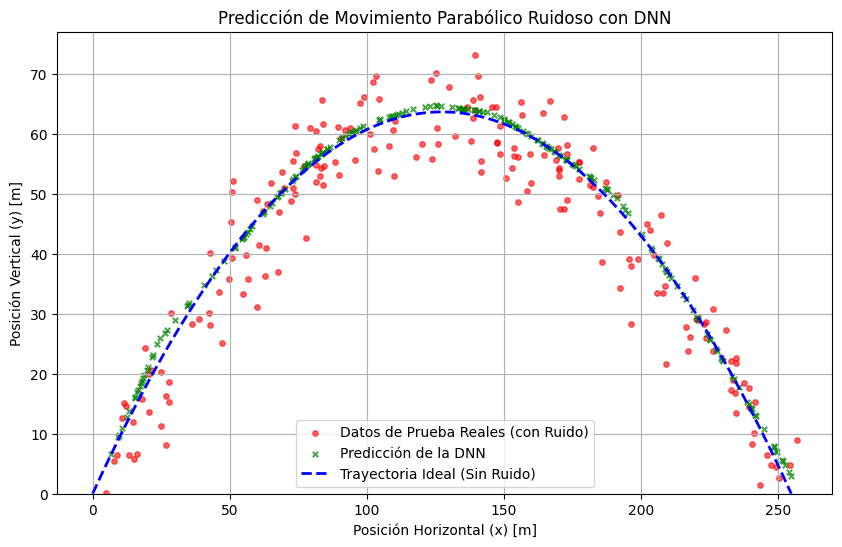

In [27]:
# --- 1. Generación de Datos Sintéticos (Mismo código que antes) ---

# Parámetros
velocidad_inicial = 50.0  # m/s
angulo_grados = 45.0      # grados
gravedad = 9.81           # m/s^2
angulo_radianes = np.deg2rad(angulo_grados)
v0x = velocidad_inicial * np.cos(angulo_radianes)
v0y = velocidad_inicial * np.sin(angulo_radianes)
tiempo_vuelo = 2 * v0y / gravedad
num_puntos = 1000  # Aumentamos los puntos para un mejor entrenamiento

# Vector de tiempo (Entrada X)
t = np.linspace(0, tiempo_vuelo, num_puntos).reshape(-1, 1) # reshape para scikit-learn

# Trayectoria Ideal
x_ideal = v0x * t
y_ideal = v0y * t - 0.5 * gravedad * t**2

# Adición de Ruido
sigma_ruido = 5.0 # Desviación estándar del ruido
ruido_x = np.random.normal(0, sigma_ruido, num_puntos).reshape(-1, 1)
ruido_y = np.random.normal(0, sigma_ruido, num_puntos).reshape(-1, 1)

# Posiciones con ruido (Salida Y)
X_data = t  # La entrada es el tiempo
Y_data = np.hstack([x_ideal + ruido_x, y_ideal + ruido_y]) # La salida es (x, y)

print(f"Forma de los datos de entrada (Tiempo): {X_data.shape}")
print(f"Forma de los datos de salida (Posición X, Y): {Y_data.shape}")

# --- 2. Normalización de Datos y División ---

# Normalizador para la entrada (Tiempo)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_data)

# Normalizador para la salida (Posiciones X e Y)
scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y_data)

# División en conjuntos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y_scaled, test_size=0.2, random_state=42
)

# --- 3. Creación y Entrenamiento de la DNN ---

# Definición del modelo (Arquitectura Profunda)
model = keras.Sequential([
    # Capa de Entrada (1 dimensión: Tiempo)
    keras.layers.Input(shape=(1,)),

    # Primera Capa Oculta (Profunda)
    keras.layers.Dense(units=32, activation='relu', name='Hidden_1'),

    # Segunda Capa Oculta
    keras.layers.Dense(units=16, activation='relu', name='Hidden_2'),

    # Tercera Capa Oculta
    #keras.layers.Dense(units=16, activation='relu', name='Hidden_3'),

    # Capa de Salida (2 dimensiones: X y Y)
    keras.layers.Dense(units=2, name='Output_Layer')
])

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='mean_squared_error', # Adecuado para regresión
    metrics=['mae'] # Error Absoluto Medio
)

# Entrenamiento del modelo
print("\nIniciando entrenamiento...")
history = model.fit(
    X_train, Y_train,
    epochs=100,          # Número de iteraciones
    batch_size=32,       # Tamaño del lote
    validation_split=0.1, # 10% del set de entrenamiento para validación
    verbose=0            # No muestra el progreso de cada época
)
print("Entrenamiento finalizado.")

# Evaluación del modelo
loss, mae = model.evaluate(X_test, Y_test, verbose=0)
print(f"\nError Cuadrático Medio (MSE) en Test: {loss:.4f}")
print(f"Error Absoluto Medio (MAE) en Test: {mae:.4f}")

# --- 4. Arquitectura de la Red y Parámetros ---

print("\nArquitectura de la Red y Parámetros (Pesos Entrenables) ##")
model.summary()

# --- 5. Predicción y Desnormalización para Visualización ---

# Predicción en el set de prueba (escalado)
Y_pred_scaled = model.predict(X_test)

# Desnormalización de las predicciones
Y_pred_denormalized = scaler_Y.inverse_transform(Y_pred_scaled)

# Desnormalización de las salidas reales de prueba (para comparar)
Y_test_denormalized = scaler_Y.inverse_transform(Y_test)

# --- 6. Visualización de Resultados ---

plt.figure(figsize=(10, 6))
plt.scatter(Y_test_denormalized[:, 0], Y_test_denormalized[:, 1],
            label='Datos de Prueba Reales (con Ruido)', alpha=0.6, s=15, color='red')
plt.scatter(Y_pred_denormalized[:, 0], Y_pred_denormalized[:, 1],
            label='Predicción de la DNN', alpha=0.7, s=15, color='green', marker='x')

plt.plot(x_ideal, y_ideal, label='Trayectoria Ideal (Sin Ruido)',
         color='blue', linestyle='--', linewidth=2)

plt.title('Predicción de Movimiento Parabólico Ruidoso con DNN')
plt.xlabel('Posición Horizontal (x) [m]')
plt.ylabel('Posición Vertical (y) [m]')
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.show()


Iniciando entrenamiento con PINN...
Pesos de Pérdida: lambda_datos = 1.0, lambda_fisica = 0.0
Epoch 20/1000 | Loss Total: 1.2672e-01 | Loss Datos: 1.2672e-01 | Loss Física: 1.5681e+02
Epoch 40/1000 | Loss Total: 3.8583e-02 | Loss Datos: 3.8583e-02 | Loss Física: 3.1587e+01
Epoch 60/1000 | Loss Total: 3.5411e-02 | Loss Datos: 3.5411e-02 | Loss Física: 1.5599e+01
Epoch 80/1000 | Loss Total: 3.5485e-02 | Loss Datos: 3.5485e-02 | Loss Física: 1.5601e+01
Epoch 100/1000 | Loss Total: 3.4591e-02 | Loss Datos: 3.4591e-02 | Loss Física: 1.2443e+01
Epoch 120/1000 | Loss Total: 3.4780e-02 | Loss Datos: 3.4780e-02 | Loss Física: 9.3562e+00
Epoch 140/1000 | Loss Total: 3.4480e-02 | Loss Datos: 3.4480e-02 | Loss Física: 1.3243e+01
Epoch 160/1000 | Loss Total: 3.4906e-02 | Loss Datos: 3.4906e-02 | Loss Física: 1.1791e+01
Epoch 180/1000 | Loss Total: 3.4331e-02 | Loss Datos: 3.4331e-02 | Loss Física: 1.7375e+01
Epoch 200/1000 | Loss Total: 3.4760e-02 | Loss Datos: 3.4760e-02 | Loss Física: 1.5522e+01

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_1 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 626 (2.45 KB)

 Trainable params: 626 (2.45 KB)

 Non-trainable params: 0 (0.00 B)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


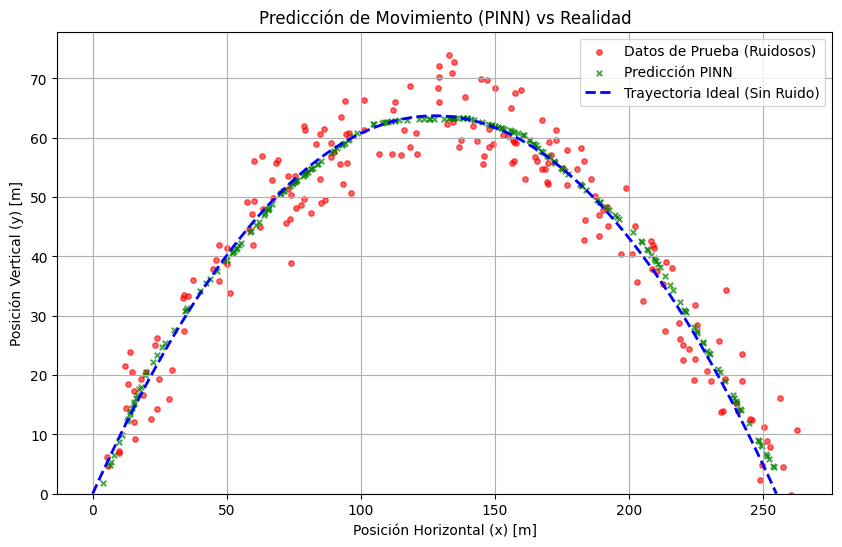

In [28]:
# --- 1. Generación de Datos Sintéticos y Parámetros ---

# Parámetros físicos
velocidad_inicial = 50.0
angulo_grados = 45.0
gravedad = 9.81
angulo_radianes = np.deg2rad(angulo_grados)
v0x = velocidad_inicial * np.cos(angulo_radianes)
v0y = velocidad_inicial * np.sin(angulo_radianes) # v_0 en la EDO
tiempo_vuelo = 2 * v0y / gravedad
num_puntos = 1000

# Vector de tiempo (Entrada X)
t = np.linspace(0, tiempo_vuelo, num_puntos).reshape(-1, 1)

# Trayectoria Ideal
x_ideal = v0x * t
y_ideal = v0y * t - 0.5 * gravedad * t**2

# Adición de Ruido
sigma_ruido = 5.0
ruido_x = np.random.normal(0, sigma_ruido, num_puntos).reshape(-1, 1)
ruido_y = np.random.normal(0, sigma_ruido, num_puntos).reshape(-1, 1)

# Datos con ruido (Entrada X, Salida Y)
X_data = t
Y_data = np.hstack([x_ideal + ruido_x, y_ideal + ruido_y])

# --- 2. Normalización de Datos (scikit-learn) ---
# Es CRUCIAL para que la red aprenda y para la derivada

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_data)

scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y_data)

# División en entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y_scaled, test_size=0.2, random_state=42
)

# Convertir a tensores de TensorFlow (necesario para GradientTape)
X_train_tf = tf.constant(X_train, dtype=tf.float32)
Y_train_tf = tf.constant(Y_train, dtype=tf.float32)

# --- 3. Definición del Modelo (Keras) ---
model = keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(32, activation='relu', name='Hidden_1'),
    keras.layers.Dense(16, activation='relu', name='Hidden_2'),
    #keras.layers.Dense(16, activation='relu', name='Hidden_3'),
    keras.layers.Dense(2, name='Output_Layer') # Salida (x, y)
])

# Optimizador
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# --- 4. Definición de la Función de Pérdida PINN ---

# Parámetros físicos y de normalización como constantes de TF
# Necesarios para la regla de la cadena en la EDO
g_tf = tf.constant(gravedad, dtype=tf.float32)
v0y_tf = tf.constant(v0y, dtype=tf.float32)

# Parámetros de normalización (media y escala)
# (x = x_scaled * scale + mean)
scale_t = tf.constant(scaler_X.scale_[0], dtype=tf.float32)
mean_t = tf.constant(scaler_X.mean_[0], dtype=tf.float32)
scale_y = tf.constant(scaler_Y.scale_[1], dtype=tf.float32) # Solo de Y
mean_y = tf.constant(scaler_Y.mean_[1], dtype=tf.float32) # Solo de Y

# -----------------------------------------------------------------
# >> AQUI ESTÁN LOS "PESOS" DE LA PÉRDIDA <<
# Estos pesos (lambda) deciden qué tan importante es cada pérdida
# -----------------------------------------------------------------
lambda_datos = 1.0  # Peso para la pérdida de datos (MSE)
lambda_fisica = 0.0 # Peso para la pérdida de la EDO (residuo)
# -----------------------------------------------------------------

@tf.function
def train_step(t_scaled, y_data_scaled):
    with tf.GradientTape() as tape:
        # 1. Pérdida de Datos (MSE estándar)
        # 'tape' observa las variables entrenables del modelo
        y_pred_scaled = model(t_scaled, training=True)
        loss_datos = tf.reduce_mean(tf.square(y_data_scaled - y_pred_scaled))

        # 2. Pérdida de Física (Residuo de la EDO)
        with tf.GradientTape() as tape_deriv:
            # 'tape_deriv' observa la entrada 't_scaled'
            tape_deriv.watch(t_scaled)
            # Predecir solo con 't_scaled'
            y_pred_scaled_inner = model(t_scaled, training=True)
            # Extraer solo la componente 'y' escalada
            y_s = y_pred_scaled_inner[:, 1] # y_scaled

        # Calcular la derivada de la salida (y_s) respecto a la entrada (t_s)
        # dy_s / dt_s
        dy_s_dt_s = tape_deriv.gradient(y_s, t_scaled)

        # ---------------------------------------------------------------
        # Aplicar Regla de la Cadena para desnormalizar la derivada
        # t = t_s * scale_t + mean_t  => dt/dt_s = scale_t
        # y = y_s * scale_y + mean_y  => dy/dy_s = scale_y
        #
        # dy/dt = (dy/dy_s) * (dy_s/dt_s) * (dt_s/dt)
        # dy/dt = scale_y * (dy_s/dt_s) * (1 / scale_t)
        # ---------------------------------------------------------------
        dy_dt_pred = (dy_s_dt_s / scale_t) * scale_y

        # Desnormalizar el tiempo para la EDO
        t_original = (t_scaled * scale_t) + mean_t

        # Calcular el valor "real" de la velocidad según la EDO
        # v_0y - g*t
        dy_dt_real = v0y_tf - g_tf * t_original

        # Calcular el residuo de la EDO
        # El objetivo es que (dy/dt_pred) - (dy/dt_real) sea CERO
        residuo = dy_dt_pred - dy_dt_real
        loss_fisica = tf.reduce_mean(tf.square(residuo))

        # 3. Pérdida Total (con los pesos lambda)
        total_loss = (lambda_datos * loss_datos) + (lambda_fisica * loss_fisica)

    # Calcular gradientes y aplicar al optimizador
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return total_loss, loss_datos, loss_fisica

# --- 5. Bucle de Entrenamiento Personalizado ---
epochs = 1000
batch_size = 32

# Crear dataset para batching
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_tf, Y_train_tf))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train_tf)).batch(batch_size)

print("\nIniciando entrenamiento con PINN...")
print(f"Pesos de Pérdida: lambda_datos = {lambda_datos}, lambda_fisica = {lambda_fisica}")

for epoch in range(epochs):
    epoch_loss_total = 0
    epoch_loss_datos = 0
    epoch_loss_fisica = 0

    for (t_batch, y_batch) in train_dataset:
        loss_total, loss_datos, loss_fisica = train_step(t_batch, y_batch)
        epoch_loss_total += loss_total.numpy()
        epoch_loss_datos += loss_datos.numpy()
        epoch_loss_fisica += loss_fisica.numpy()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Loss Total: {epoch_loss_total/len(train_dataset):.4e} | "
              f"Loss Datos: {epoch_loss_datos/len(train_dataset):.4e} | "
              f"Loss Física: {epoch_loss_fisica/len(train_dataset):.4e}")

print("Entrenamiento finalizado.")

# --- 6. Mostrar Arquitectura y Parámetros del Modelo ---
print("\n## 📊 Arquitectura de la Red y Parámetros (Pesos Entrenables) ##")
model.summary()

# --- 7. Visualización ---
# Predicción en el set de prueba (escalado)
Y_pred_scaled = model.predict(X_test)

# Desnormalización
Y_pred_denormalized = scaler_Y.inverse_transform(Y_pred_scaled)
Y_test_denormalized = scaler_Y.inverse_transform(Y_test)

plt.figure(figsize=(10, 6))
plt.scatter(Y_test_denormalized[:, 0], Y_test_denormalized[:, 1],
            label='Datos de Prueba (Ruidosos)', alpha=0.6, s=15, color='red')
plt.scatter(Y_pred_denormalized[:, 0], Y_pred_denormalized[:, 1],
            label='Predicción PINN', alpha=0.7, s=15, color='green', marker='x')

plt.plot(x_ideal, y_ideal, label='Trayectoria Ideal (Sin Ruido)',
         color='blue', linestyle='--', linewidth=2)
plt.title('Predicción de Movimiento (PINN) vs Realidad')
plt.xlabel('Posición Horizontal (x) [m]')
plt.ylabel('Posición Vertical (y) [m]')
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.show()


Iniciando entrenamiento con PINN (Datos + EDO + IC)...
Pesos: lambda_datos = 0.2, lambda_fisica = 0.5, lambda_ic = 0.3
Epoch 20/750 | L_Total: 1.3378e+01 | L_Datos: 4.0033e-01 | L_Física: 2.6506e+01 | L_IC: 1.4931e-01
Epoch 40/750 | L_Total: 1.9808e+00 | L_Datos: 9.1610e-02 | L_Física: 3.9237e+00 | L_IC: 2.0762e-03
Epoch 60/750 | L_Total: 1.2264e+00 | L_Datos: 4.6742e-02 | L_Física: 2.4340e+00 | L_IC: 6.4711e-05
Epoch 80/750 | L_Total: 8.3244e-01 | L_Datos: 3.9222e-02 | L_Física: 1.6491e+00 | L_IC: 5.6494e-05
Epoch 100/750 | L_Total: 8.5606e-01 | L_Datos: 3.8232e-02 | L_Física: 1.6968e+00 | L_IC: 2.7531e-05
Epoch 120/750 | L_Total: 9.6957e-01 | L_Datos: 3.7769e-02 | L_Física: 1.9240e+00 | L_IC: 2.7360e-05
Epoch 140/750 | L_Total: 8.5507e-01 | L_Datos: 3.7435e-02 | L_Física: 1.6951e+00 | L_IC: 4.6601e-05
Epoch 160/750 | L_Total: 8.3886e-01 | L_Datos: 3.6472e-02 | L_Física: 1.6631e+00 | L_IC: 7.1833e-05
Epoch 180/750 | L_Total: 8.8900e-01 | L_Datos: 3.6875e-02 | L_Física: 1.7631e+00 | L

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_1 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 626 (2.45 KB)

 Trainable params: 626 (2.45 KB)

 Non-trainable params: 0 (0.00 B)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


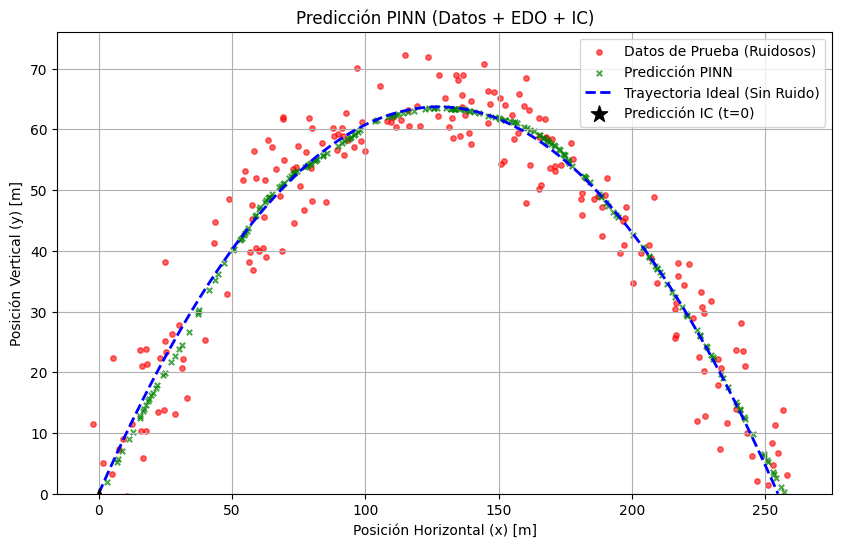

In [30]:
# --- 1. Generación de Datos Sintéticos y Parámetros ---
# (Sin cambios respecto al código anterior)
velocidad_inicial = 50.0
angulo_grados = 45.0
gravedad = 9.81
angulo_radianes = np.deg2rad(angulo_grados)
v0x = velocidad_inicial * np.cos(angulo_radianes)
v0y = velocidad_inicial * np.sin(angulo_radianes)
tiempo_vuelo = 2 * v0y / gravedad
num_puntos = 1000

t = np.linspace(0, tiempo_vuelo, num_puntos).reshape(-1, 1)
x_ideal = v0x * t
y_ideal = v0y * t - 0.5 * gravedad * t**2

sigma_ruido = 5.0
ruido_x = np.random.normal(0, sigma_ruido, num_puntos).reshape(-1, 1)
ruido_y = np.random.normal(0, sigma_ruido, num_puntos).reshape(-1, 1)

X_data = t
Y_data = np.hstack([x_ideal + ruido_x, y_ideal + ruido_y])

# --- 2. Normalización de Datos y Puntos de Condición Inicial (IC) ---

# Ajustar los escaladores
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_data)
scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y_data)

# >> NUEVO: Crear los puntos de la Condición Inicial (t=0, x=0, y=0) <<
# Debemos escalarlos usando los MISMOS escaladores
t_ic_original = np.array([[0.0]])
y_ic_original = np.array([[0.0, 0.0]]) # [x=0, y=0]

t_ic_scaled = scaler_X.transform(t_ic_original)
y_ic_scaled = scaler_Y.transform(y_ic_original)

# Convertir los puntos IC a tensores constantes de TF
t_ic_tf = tf.constant(t_ic_scaled, dtype=tf.float32)
y_ic_tf = tf.constant(y_ic_scaled, dtype=tf.float32)

# División en entrenamiento y prueba (para los datos de entrenamiento ruidosos)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y_scaled, test_size=0.2, random_state=42
)

# Convertir datos de entrenamiento a tensores
X_train_tf = tf.constant(X_train, dtype=tf.float32)
Y_train_tf = tf.constant(Y_train, dtype=tf.float32)

# --- 3. Definición del Modelo (Keras) ---
# (Sin cambios)
model = keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(32, activation='relu', name='Hidden_1'),
    keras.layers.Dense(16, activation='relu', name='Hidden_2'),
    #keras.layers.Dense(32, activation='relu', name='Hidden_3'),
    keras.layers.Dense(2, name='Output_Layer') # Salida (x, y)
])

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# --- 4. Definición de la Función de Pérdida PINN (con IC) ---

# Parámetros físicos y de normalización como constantes de TF
g_tf = tf.constant(gravedad, dtype=tf.float32)
v0y_tf = tf.constant(v0y, dtype=tf.float32)
scale_t = tf.constant(scaler_X.scale_[0], dtype=tf.float32)
mean_t = tf.constant(scaler_X.mean_[0], dtype=tf.float32)
scale_y = tf.constant(scaler_Y.scale_[1], dtype=tf.float32)
mean_y = tf.constant(scaler_Y.mean_[1], dtype=tf.float32)

# -----------------------------------------------------------------
# >> AQUI ESTÁN LOS PESOS DE LA PÉRDIDA <<
# -----------------------------------------------------------------
lambda_datos = 0.2  # Peso para los datos ruidosos (MSE)
lambda_fisica = 0.5 # Peso para la EDO (residuo)
lambda_ic = 0.3     # Peso para la Condición Inicial
# -----------------------------------------------------------------

@tf.function
def train_step(t_scaled_batch, y_data_scaled_batch):
    with tf.GradientTape() as tape:
        # 1. Pérdida de Datos (MSE estándar en el batch)
        y_pred_scaled = model(t_scaled_batch, training=True)
        loss_datos = tf.reduce_mean(tf.square(y_data_scaled_batch - y_pred_scaled))

        # 2. Pérdida de Física (Residuo de la EDO en el batch)
        with tf.GradientTape() as tape_deriv:
            tape_deriv.watch(t_scaled_batch)
            y_pred_scaled_inner = model(t_scaled_batch, training=True)
            y_s = y_pred_scaled_inner[:, 1] # y_scaled

        dy_s_dt_s = tape_deriv.gradient(y_s, t_scaled_batch)

        # Regla de la cadena para desnormalizar la derivada
        dy_dt_pred = (dy_s_dt_s / scale_t) * scale_y
        t_original = (t_scaled_batch * scale_t) + mean_t
        dy_dt_real = v0y_tf - g_tf * t_original

        residuo = dy_dt_pred - dy_dt_real
        loss_fisica = tf.reduce_mean(tf.square(residuo))

        # 3. >> NUEVO: Pérdida de Condición Inicial (IC) <<
        # Calculada solo en el punto t=0
        y_pred_ic_scaled = model(t_ic_tf, training=True)
        loss_ic = tf.reduce_mean(tf.square(y_ic_tf - y_pred_ic_scaled))

        # 4. Pérdida Total (con los tres pesos lambda)
        total_loss = (lambda_datos * loss_datos) + \
                     (lambda_fisica * loss_fisica) + \
                     (lambda_ic * loss_ic)

    # Calcular gradientes y aplicar al optimizador
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return total_loss, loss_datos, loss_fisica, loss_ic

# --- 5. Bucle de Entrenamiento Personalizado ---
epochs = 750
batch_size = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_tf, Y_train_tf))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train_tf)).batch(batch_size)

print("\nIniciando entrenamiento con PINN (Datos + EDO + IC)...")
print(f"Pesos: lambda_datos = {lambda_datos}, lambda_fisica = {lambda_fisica}, lambda_ic = {lambda_ic}")

for epoch in range(epochs):
    epoch_loss_total = 0
    epoch_loss_datos = 0
    epoch_loss_fisica = 0
    epoch_loss_ic = 0

    for (t_batch, y_batch) in train_dataset:
        loss_total, loss_datos, loss_fisica, loss_ic = train_step(t_batch, y_batch)
        epoch_loss_total += loss_total.numpy()
        epoch_loss_datos += loss_datos.numpy()
        epoch_loss_fisica += loss_fisica.numpy()
        epoch_loss_ic += loss_ic.numpy() # Acumular la pérdida IC

    if (epoch + 1) % 20 == 0:
        num_batches = len(train_dataset)
        print(f"Epoch {epoch+1}/{epochs} | "
              f"L_Total: {epoch_loss_total/num_batches:.4e} | "
              f"L_Datos: {epoch_loss_datos/num_batches:.4e} | "
              f"L_Física: {epoch_loss_fisica/num_batches:.4e} | "
              f"L_IC: {epoch_loss_ic/num_batches:.4e}") # Imprimir la pérdida IC

print("Entrenamiento finalizado.")

# --- 6. Mostrar Arquitectura y Parámetros del Modelo ---
print("\n## 📊 Arquitectura de la Red y Parámetros (Pesos Entrenables) ##")
model.summary()

# --- 7. Visualización ---
# (Sin cambios)
Y_pred_scaled = model.predict(X_test)
Y_pred_denormalized = scaler_Y.inverse_transform(Y_pred_scaled)
Y_test_denormalized = scaler_Y.inverse_transform(Y_test)

plt.figure(figsize=(10, 6))
plt.scatter(Y_test_denormalized[:, 0], Y_test_denormalized[:, 1],
            label='Datos de Prueba (Ruidosos)', alpha=0.6, s=15, color='red')
plt.scatter(Y_pred_denormalized[:, 0], Y_pred_denormalized[:, 1],
            label='Predicción PINN', alpha=0.7, s=15, color='green', marker='x')
plt.plot(x_ideal, y_ideal, label='Trayectoria Ideal (Sin Ruido)',
         color='blue', linestyle='--', linewidth=2)
# Añadir un punto para mostrar dónde la PINN cree que está t=0
y_pred_ic_denorm = scaler_Y.inverse_transform(model.predict(t_ic_tf))
plt.scatter(y_pred_ic_denorm[:, 0], y_pred_ic_denorm[:, 1],
            label='Predicción IC (t=0)', color='black', marker='*', s=150, zorder=5)

plt.title('Predicción PINN (Datos + EDO + IC)')
plt.xlabel('Posición Horizontal (x) [m]')
plt.ylabel('Posición Vertical (y) [m]')
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.show()